from google.colab import drive
drive.mount("/content/MyDrive")

##Librairies

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
import hashlib
from tqdm.notebook import tqdm
import os
warnings.filterwarnings('ignore')
import psutil
import seaborn as sns
from sklearn.preprocessing import LabelEncoder
from transformers import RobertaTokenizer,AutoTokenizer,AutoConfig,BertForPreTraining,AutoModel,BertModel
import torch
import torch.nn as nn
from torch.utils.data import Dataset,DataLoader,TensorDataset
import torch.nn.functional as F
from transformers import get_linear_schedule_with_warmup
from collections import defaultdict
from sklearn.model_selection import train_test_split
import random
from torch.optim import AdamW
import time

In [2]:
def class_balanced_downsample(df, target_col, keep_frac=0.5, random_state=42, min_samples=20):
    """
    Downsamples the top n/2 most populated classes based on keep_frac.
    The bottom n/2 least populated classes are kept untouched.
    
    At keep_frac=1.0, nothing is dropped.
    At keep_frac=0.0, top i classes are reduced to size of the (i+1)th class,
    but never below min_samples.

    Parameters:
    - df: pd.DataFrame
    - target_col: str
    - keep_frac: float ∈ [0, 1], how much of each top-class population to retain
    - random_state: int
    - min_samples: int, minimum samples to keep per downsampled class

    Returns:
    - pd.DataFrame with class-balanced downsampling
    """
    import pandas as pd
    
    assert 0.0 <= keep_frac <= 1.0, "keep_frac must be between 0 and 1."

    # Get class sizes in descending order
    class_counts = df[target_col].value_counts()
    sorted_classes = class_counts.index.tolist()
    num_classes = len(sorted_classes)
    cutoff = num_classes - 1  # Number of most populated classes to downsample

    # Class used as downsampling baseline
    base_class = sorted_classes[cutoff]
    base_count = class_counts[base_class]

    sampled_dfs = []

    for i, cls in enumerate(sorted_classes):
        class_df = df[df[target_col] == cls]
        count = len(class_df)

        if i < cutoff:
            # Compute target count between original and base_count
            target_count = int(keep_frac * count + (1 - keep_frac) * base_count)
            target_count = min(target_count, count)
            # Enforce minimum samples per class
            if target_count < min_samples:
                target_count = min_samples if min_samples <= count else count
            class_df = class_df.sample(n=target_count, random_state=random_state)
        
        # Lower half of classes: untouched
        sampled_dfs.append(class_df)

    return pd.concat(sampled_dfs).reset_index(drop=True)

In [3]:
keep_frac = 1.0

In [4]:
import os
os.environ["CUDA_LAUNCH_BLOCKING"] = "1"

In [5]:
def memory_check():
  return round(psutil.virtual_memory().used/1024**3,3)

os.chdir('/content/MyDrive/MyDrive/Colab Notebooks/securityBERT')

##PPFLE Algorithm

In [6]:
def H(x):
  hasher = hashlib.sha1() #returns a hashed value of 256 bits
  hasher.update(x.encode('utf-8'))
  hashed = hasher.hexdigest()

  return hashed


In [7]:
def s(i,j):
  return str(i)+"$"+str(j) #To concatenate the column name with the cell value

In [8]:
def PPFLE(M, columns):
  # print(columns)
  # return 0
  DL = []
  for i,v in tqdm(M.iterrows(),desc="Processing...",total=len(M)):
    L = []
    for j in columns:
      L.append(H(s(j,v.get(j))))
    DL.append(" ".join(L))
  return DL


In [9]:
# features_to_remove = ['frame.time','ip.src_host', 'ip.dst_host','arp.dst.proto_ipv4','tcp.payload']
# print(data.shape)
# data = data.drop(columns=features_to_remove,axis=0)
# data.shape

In [10]:
data = pd.read_csv(".\data\Edge-IIoTset dataset\Selected dataset for ML and DL\ML-EdgeIIoT-dataset.csv")
data.head(5)

,frame.time,ip.src_host,ip.dst_host,arp.dst.proto_ipv4,arp.opcode,arp.hw.size,arp.src.proto_ipv4,icmp.checksum,icmp.seq_le,icmp.transmit_timestamp,...,mqtt.proto_len,mqtt.protoname,mqtt.topic,mqtt.topic_len,mqtt.ver,mbtcp.len,mbtcp.trans_id,mbtcp.unit_id,Attack_label,Attack_type
0,6.0,192.168.0.152,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1,MITM
1,6.0,192.168.0.101,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1,MITM
2,6.0,192.168.0.152,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1,MITM
3,6.0,192.168.0.101,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1,MITM
4,6.0,192.168.0.152,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1,MITM


In [11]:
label_col = "Attack_type"  # or the actual name of your attack type column

if (keep_frac > 0) and (keep_frac < 1.0):
    print(f"Data shape before reduction: {data.shape}")
    data = class_balanced_downsample(data, label_col, keep_frac=keep_frac)
    print(f"Data shape after reduction: {data.shape}")

In [12]:
data['Attack_type'].value_counts()

Attack_type
Normal                   24301
DDoS_UDP                 14498
DDoS_ICMP                14090
Ransomware               10925
DDoS_HTTP                10561
SQL_injection            10311
Uploading                10269
DDoS_TCP                 10247
Backdoor                 10195
Vulnerability_scanner    10076
Port_Scanning            10071
XSS                      10052
Password                  9989
MITM                      1214
Fingerprinting            1001
Name: count, dtype: int64

In [13]:
columns_object = data.select_dtypes(include=['object']).columns
columns_object = list(columns_object[:-2])

In [14]:
for column in tqdm(columns_object):
  data[column] = data[column].astype(str)


  0%|          | 0/18 [00:00<?, ?it/s]

In [15]:
data.sample(5)

,frame.time,ip.src_host,ip.dst_host,arp.dst.proto_ipv4,arp.opcode,arp.hw.size,arp.src.proto_ipv4,icmp.checksum,icmp.seq_le,icmp.transmit_timestamp,...,mqtt.proto_len,mqtt.protoname,mqtt.topic,mqtt.topic_len,mqtt.ver,mbtcp.len,mbtcp.trans_id,mbtcp.unit_id,Attack_label,Attack_type
14695,2021 23:10:32.153317000,192.168.0.128,192.168.0.170,0,0.0,0.0,0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1,Uploading
121075,2021 19:29:08.953062000,192.168.0.128,192.168.0.101,0,0.0,0.0,0,0.0,0.0,0.0,...,0.0,0,0,0.0,0.0,0.0,0.0,0.0,0,Normal
21357,2021 23:14:00.699663000,192.168.0.170,192.168.0.128,0,0.0,0.0,0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1,Uploading
30744,2021 21:41:29.586689000,192.168.0.170,192.168.0.128,0,0.0,0.0,0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1,SQL_injection
10575,2021 23:54:04.522605000,192.168.0.128,192.168.0.170,0,0.0,0.0,0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1,Ransomware


In [16]:
temp = PPFLE(data, list(data.columns[:-2]))

Processing...:   0%|          | 0/157800 [00:00<?, ?it/s]

for idx, col in enumerate(data.columns):
    print(f"Index {idx}: Column '{col}'")
    print()  # Add empty line for spacing

-Index 1: Column 'ip.src_host'

-Index 2: Column 'ip.dst_host'

-Index 27: Column 'tcp.dstport'

-Index 32: Column 'tcp.payload'

-Index 34: Column 'tcp.srcport'

-Index 35: Column 'udp.port'

-Index 54: Column 'mqtt.protoname'

In [17]:
data['encoded_PPFLE'] = temp
del temp

In [18]:
data = data[['encoded_PPFLE','Attack_type','Attack_label']]

In [19]:
data.to_pickle('./saved_data/encoded_data.pck')

##Load saved data

In [20]:
data = pd.read_pickle('./saved_data/encoded_data.pck')

In [21]:
le = LabelEncoder()
data['target'] = le.fit_transform(data['Attack_type'])

In [22]:
data.sample(3)

,encoded_PPFLE,Attack_type,Attack_label,target
28916,5456d4103c972d03637d54f9ddba513c546ebfcf 0bc16...,SQL_injection,1,11
87607,dae365c77ffcf653da2de3e29cdbd0e1a14a8d9a 6df8d...,Backdoor,1,0
58158,683570cbb550d874fc917d76f586fa25c6749f67 0bc16...,Password,1,8


In [23]:
data['encoded_PPFLE'][0]

'689e1d00f39f485bd2da5098239199df85c39b4d 2ab932d3aadb7887eda7302e0b33df13dc5ca645 f2c86566785eaad29f5c4b244d058b0cb7deb97e 5ea155b76662c1b381a0526e87d733a2ae68bfce b3625a98258ceacc69889389baca3b048a4923e4 8d419a4b06c3bd95d00fe2ee5cf1146851cf9893 c71f6d1e2daf2f598381088226df35ae68552f0b b7036347f54fa5aef0dd3f66b4e44c56bbf54cf4 f97d947902327761a4b1472d76b71bf4406e4e18 79ae7b95cace51fb0079d9c5ef1641f4639ce3ed ea25a11eb9c83b7d70252710098ded6bc81eb62b ceae604760aaa4fd8b60791ae1839b754c2dd9f1 23197a0ba8a217f2bc8711ec3c4be39dc19236d7 e2df55df19acd4423bafccbb0b8a385ec5e914eb f086df09fafdda401160bc766631e3d5785a6257 5329d5d159837e103352035068b3e14ce570d7eb 3eb6e4b9dd1c085a3ad0b18484d48482c935a4f7 943315f7b6cb0fc45604f5cf2ac307894e59b990 89b029338e8dd73f49369cd01c0052663c8c949e f91e2919e7494d796d1148066124d4b4939c86fa a5ce077c8900f85e073032ae975d95491645ddce effcfb2aa80217f507218ea88726c9325a0d68b9 bf12d74b6502b4fc1e29df164d3bf6f6ce51ffe3 7d69c36dbc4a37fc6643a32e914ea4e7ee0f0fc2 128f4c3fdc8539e

In [24]:
sorted(data['target'].unique())

[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14]

In [25]:
# data.to_pickle('./encoded_data.pickle')

In [26]:
memory_check()

20.363

In [27]:
with open("encoded_data.txt","w") as f:
  for value in tqdm(data['encoded_PPFLE']):
    f.write(str(value)+'\n')


  0%|          | 0/157800 [00:00<?, ?it/s]

##Data splitting

In [28]:
train_set = data.sample(frac=0.7,random_state=42).reset_index(drop=True)

remaining = data.drop(train_set.index).reset_index(drop=True)

test_set = remaining.sample(frac=0.5,random_state=42).reset_index(drop=True)

val_set = remaining.drop(test_set.index).reset_index(drop=True)

print(train_set.shape,val_set.shape,test_set.shape)

(110460, 4) (23670, 4) (23670, 4)


In [29]:
train_ratio = 0.7
val_ratio = 0.15
test_ratio = 0.15

In [30]:
train_set, test_set = train_test_split(data, test_size=test_ratio,stratify=data.iloc[:,-1], random_state=42)
train_set, val_set = train_test_split(train_set, test_size=val_ratio/(val_ratio+train_ratio),stratify=train_set.iloc[:,-1], random_state=42)


In [31]:
train_set.shape,val_set.shape,test_set.shape

((110460, 4), (23670, 4), (23670, 4))

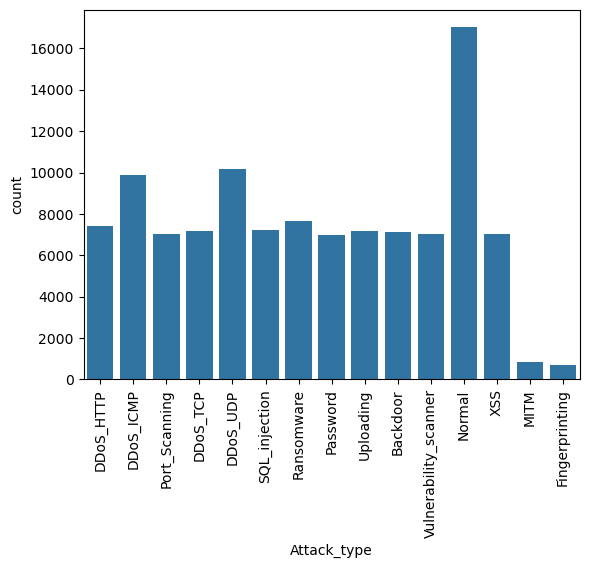

In [32]:
sns.countplot(train_set,x='Attack_type');
plt.xticks(rotation=90)
plt.show();

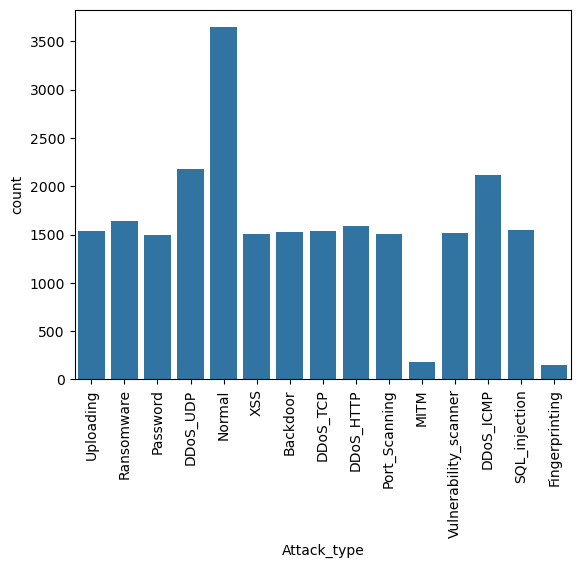

In [33]:
sns.countplot(val_set,x='Attack_type');
plt.xticks(rotation=90)
plt.show();

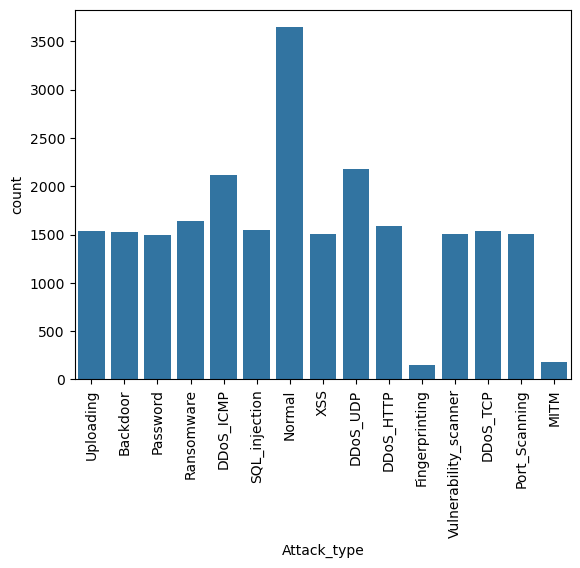

In [34]:
sns.countplot(test_set,x='Attack_type');
plt.xticks(rotation=90)
plt.show();

In [35]:
TARGET_LIST = ['Backdoor', 'DDoS_HTTP', 'DDoS_ICMP', 'DDoS_TCP', 'DDoS_UDP',
                'Fingerprinting', 'MITM', 'Normal', 'Password', 'Port_Scanning',
                'Ransomware', 'SQL_injection', 'Uploading', 'Vulnerability_scanner',
                'XSS']

In [36]:
data[data['Attack_type']=='Uploading'].head(5)

,encoded_PPFLE,Attack_type,Attack_label,target
13140,05293357ba325a590027981a9b59eb748a968bb8 0bc16...,Uploading,1,12
13141,da0992898db14d190c3b6f7c2c6c658259a2b3a4 0bc16...,Uploading,1,12
13142,4d5b89f0a6797f41a5d0ee5b7b1cfe1327a291f4 0bc16...,Uploading,1,12
13143,732fcefab7fb269fd8ae7bd4d3b3e28ec3310e1f 6df8d...,Uploading,1,12
13144,9a7d459b7d8a0e5c070cb85c3b1bd0824a7b010f 0bc16...,Uploading,1,12


##BBPE algorithm

In [37]:
device = torch.device("cuda" if torch.cuda.is_available() else 'cpu')
device

device(type='cuda')

In [38]:
from tokenizers import ByteLevelBPETokenizer
tokenizer = ByteLevelBPETokenizer()

In [39]:
SPECIAL_TOKENS = [
    '<pad>',
    '<s>',
    '</s>',
    '<mask>',
    '<unk>'
]
VOCAB_SIZE = 5000
EMBED_DIM = 768     # or whatever you configure BERT with

In [40]:
%%time
tokenizer.train('./encoded_data.txt',vocab_size=VOCAB_SIZE,min_frequency=2,
                special_tokens=SPECIAL_TOKENS)

CPU times: total: 4min 11s
Wall time: 14.9 s


os.mkdir('tokenizer')

In [41]:
tokenizer.save_model("./tokenizer/")

['./tokenizer/vocab.json', './tokenizer/merges.txt']

##Model section

In [42]:
tokenizer = RobertaTokenizer.from_pretrained('./tokenizer')

In [43]:
len(tokenizer.get_vocab())

5000

In [44]:
SPECIAL_TOKEN_IDS = {
    "cls": tokenizer.convert_tokens_to_ids("<s>"),
    "sep": tokenizer.convert_tokens_to_ids("</s>"),
    "pad": tokenizer.pad_token_id,
    "unk": tokenizer.unk_token_id,
    "mask": tokenizer.mask_token_id
}

In [45]:
def get_pretrain_columns(tmp_set):
    # Indices to keep
    selected_indices = [1, 2, 27, 34, 35, 54]

    # Payload
    tmp_set['payload'] = tmp_set['encoded_PPFLE'].apply(
        lambda x: ' '.join([x.split()[i] for i in [32] if i < len(x.split())])
    )

    # Apply the transformation to each row in the column
    tmp_set['encoded_PPFLE'] = tmp_set['encoded_PPFLE'].apply(
        lambda x: ' '.join([x.split()[i] for i in selected_indices if i < len(x.split())])
    )

    return tmp_set

In [46]:
from copy import deepcopy

train_set_pretrain = deepcopy(train_set)
train_set_pretrain = get_pretrain_columns(train_set_pretrain)
val_set_pretrain = deepcopy(val_set)
val_set_pretrain = get_pretrain_columns(val_set_pretrain)
test_set_pretrain = deepcopy(test_set)
test_set_pretrain = get_pretrain_columns(test_set_pretrain)

In [47]:
def build_input_sequence(sentence_a, sentence_b=None, max_len=512):
    tokens = ["<s>"]
    segment_ids = [0]

    for word in sentence_a:
        tokens.append(word)
        #assert all(0 <= t < VOCAB_SIZE+5 for t in tokens), f"Token ID out of range: {tokens}"
        segment_ids.append(0)

    if sentence_b:
        tokens.append("</s>")
        segment_ids.append(0)

        for word in sentence_b:
            tokens.append(word)
            #assert all(0 <= t < VOCAB_SIZE+5 for t in tokens), f"Token ID out of range: {tokens}"
            segment_ids.append(1)

        tokens.append("</s>")
        segment_ids.append(1)
    else:
        tokens.append("</s>")
        segment_ids.append(0)

    # Padding
    if len(tokens) < max_len:
        pad_len = max_len - len(tokens)
        tokens += ["<pad>"] * pad_len
        segment_ids += [0] * pad_len
    token_ids = tokenizer.convert_tokens_to_ids(tokens[:max_len])

    return torch.tensor(token_ids), torch.tensor(segment_ids[:max_len])


In [48]:
MASK_TOKEN_ID = SPECIAL_TOKEN_IDS["mask"]
PAD_TOKEN_ID = SPECIAL_TOKEN_IDS["pad"]

class IoVPretrainDataset(Dataset):
    def __init__(self, sentence_pairs, vocab_size=VOCAB_SIZE, max_len=512, mask_prob=0.15):
        """
        sentence_pairs: list of {"byte_sentence_a": [...], "byte_sentence_b": [...], "is_next": bool}
        """
        self.sentence_pairs = sentence_pairs
        self.vocab_size = vocab_size
        self.max_len = max_len
        self.mask_prob = mask_prob

    def __len__(self):
        return len(self.sentence_pairs)

    def __getitem__(self, idx):
        item = self.sentence_pairs[idx]
        sentence_a = item["byte_sentence_a"]
        sentence_b = item["byte_sentence_b"]
        is_next = item.get("is_next", 1)  # 1: true next sentence, 0: random sentence

        token_ids, segment_ids = build_input_sequence(sentence_a, sentence_b, self.max_len)
        masked_token_ids, labels = self.apply_masking(token_ids)
        assert not torch.isnan(masked_token_ids).any()
        assert not torch.isinf(masked_token_ids).any()
        attention_mask = (masked_token_ids != PAD_TOKEN_ID).long()
        assert masked_token_ids.max() < self.vocab_size, f"Found token ID {masked_token_ids.max()} >= vocab_size {self.vocab_size}"
        if (attention_mask != -100).sum() == 0:
            print("All MLM labels are -100 — skipping loss")


        return {
            "input_ids": masked_token_ids,
            "attention_mask": attention_mask,
            "token_type_ids": segment_ids,
            "labels": labels,
            "nsp_labels": torch.tensor(is_next, dtype=torch.long)
        }

    def apply_masking(self, token_ids: torch.Tensor) -> tuple[torch.Tensor, torch.Tensor]:
        """
        Apply 15% masking to token_ids.
        Returns:
            - masked_input_ids
            - labels (only non -100 positions are used in loss)
        """
        input_ids = token_ids.clone()
        labels = torch.full(input_ids.shape, -100)  # default ignore index

        for i in range(1, len(input_ids)):  # skip [CLS]
            if input_ids[i].item() in SPECIAL_TOKEN_IDS.values():
                continue

            if random.random() < self.mask_prob:
                labels[i] = input_ids[i].item()  # save original for prediction

                rand_val = random.random()
                if rand_val < 0.8:
                    input_ids[i] = MASK_TOKEN_ID
                elif rand_val < 0.9:
                    input_ids[i] = random.randint(0, self.vocab_size - 1)
                else:
                    pass  # keep original

        if (labels != -100).sum() == 0:
            for i in range(1, len(input_ids)):
                if input_ids[i].item() not in SPECIAL_TOKEN_IDS.values():
                    labels[i] = input_ids[i].item()
                    input_ids[i] = MASK_TOKEN_ID
                    break
        return input_ids, labels


##Dataset and DataLoader

In [49]:
class CustomDataset(Dataset):
  def __init__(self,df,tokenizer,max_len):
    self.df = df
    self.tokenizer = tokenizer
    self.max_len=max_len
    self.sequence = self.df['encoded_PPFLE'].tolist()
    self.targets = self.df['target'].tolist()

  def __len__(self):
    return len(self.df)

  def __getitem__(self,idx):
    sequence = str(self.sequence[idx])
    target = self.targets[idx]
    encoding = self.tokenizer.encode_plus(
        sequence,
        add_special_tokens=True,
        max_length=self.max_len,
        padding='max_length',
        return_token_type_ids=False,
        truncation=True,
        return_attention_mask=True,
        return_tensors='pt'
    )

    return {
        'input_ids':encoding['input_ids'].flatten(),
        'attention_mask':encoding['attention_mask'].flatten(),
        'targets':torch.tensor(target,dtype=torch.long)
    }


In [50]:
class BidirectionalSemanticExtractor:
    def __init__(self, columns = ["src_ip", "dst_ip", "src_port", "dst_port", "protocol"], window_size=2, step_size=1):
        self.window_size = window_size
        self.step_size = step_size
        self.columns = columns

    def extract_sessions(self, packets: list[dict]) -> dict:
        """
        Organizes packets into sessions based on a tuple
        Each packet is assumed to be a dictionary with necessary fields.
        """
        sessions = {}
        for pkt in packets:
            key = tuple(pkt[col] for col in self.columns)
            sessions.setdefault(key, []).append(pkt)
        return sessions

    def sliding_window_pairs(self, session_packets: list[dict]) -> list[tuple[list[str], list[str]]]:
        """
        Generates byte sentence pairs (sentence_a, sentence_b) using USE.
        """
        pairs = []
        for i in range(0, len(session_packets) - self.window_size + 1, self.step_size):
            pkt_a = session_packets[i]
            pkt_b = session_packets[i + 1]

            sentence_a = pkt_a["payload"]
            sentence_b = pkt_b["payload"]
            pairs.append((sentence_a, sentence_b))
        return pairs

    def process(self, packets: list[dict]) -> list[dict]:
        """
        Main function to extract training samples from raw packet list.
        Returns a list of training samples with byte_sentence_a and byte_sentence_b.
        """
        bsl = []
        sessions = self.extract_sessions(packets)
        for session_key, pkt_list in sessions.items():
            pairs = self.sliding_window_pairs(pkt_list)
            for sa, sb in pairs:
                bsl.append({
                    "byte_sentence_a": sa,
                    "byte_sentence_b": sb
                })
        return bsl


In [51]:
class IoVInputEmbedding(nn.Module):
    def __init__(self, vocab_size=VOCAB_SIZE, embed_dim=EMBED_DIM, max_len=512):
        super().__init__()
        self.token_embedding = nn.Embedding(vocab_size, embed_dim)
        self.segment_embedding = nn.Embedding(2, embed_dim)  # 0: sentence A, 1: sentence B
        self.position_embedding = nn.Embedding(max_len, embed_dim)

    def forward(self, token_ids: torch.Tensor, segment_ids: torch.Tensor):
        """
        token_ids: (batch_size, seq_len)
        segment_ids: (batch_size, seq_len)
        Returns:
            embeddings: (batch_size, seq_len, embed_dim)
        """

        assert (token_ids < VOCAB_SIZE).all(), \
            f"Found input_ids >= vocab_size ({VOCAB_SIZE})"

        seq_len = token_ids.size(1)
        position_ids = torch.arange(seq_len, dtype=torch.long, device=token_ids.device)
        position_ids = position_ids.unsqueeze(0).expand_as(token_ids)

        token_embed = self.token_embedding(token_ids)
        segment_embed = self.segment_embedding(segment_ids)
        position_embed = self.position_embedding(position_ids)

        return token_embed + segment_embed + position_embed


In [52]:
MAX_LEN=512
BATCH_SIZE=32

In [53]:
train_dataset = CustomDataset(train_set,tokenizer=tokenizer,max_len=MAX_LEN)
val_dataset = CustomDataset(val_set,tokenizer=tokenizer,max_len=MAX_LEN)
test_dataset = CustomDataset(test_set,tokenizer=tokenizer,max_len=MAX_LEN)

In [54]:
train_loader = DataLoader(
    train_dataset,
    shuffle=True,
    batch_size=BATCH_SIZE,
    num_workers=0

)

val_loader = DataLoader(
    val_dataset,
    shuffle=False,
    batch_size=BATCH_SIZE,
    num_workers=0

)

test_loader = DataLoader(
    test_dataset,
    shuffle=False,
    batch_size=BATCH_SIZE,
    num_workers=0

)

#Fine tuning BERT

In [55]:
config = AutoConfig.from_pretrained("bert-base-uncased")
config

BertConfig {
  "architectures": [
    "BertForMaskedLM"
  ],
  "attention_probs_dropout_prob": 0.1,
  "classifier_dropout": null,
  "gradient_checkpointing": false,
  "hidden_act": "gelu",
  "hidden_dropout_prob": 0.1,
  "hidden_size": 768,
  "initializer_range": 0.02,
  "intermediate_size": 3072,
  "layer_norm_eps": 1e-12,
  "max_position_embeddings": 512,
  "model_type": "bert",
  "num_attention_heads": 12,
  "num_hidden_layers": 12,
  "pad_token_id": 0,
  "position_embedding_type": "absolute",
  "transformers_version": "4.53.0.dev0",
  "type_vocab_size": 2,
  "use_cache": true,
  "vocab_size": 30522
}

In [56]:
config.hidden_size = 256
config.num_hidden_layers = 4
config.num_attention_heads = 16
config.intermediate_size = 512
config.vocab_size=VOCAB_SIZE


In [57]:
finetunedBERT = AutoModel.from_config(config)

In [58]:
finetunedBERT

BertModel(
  (embeddings): BertEmbeddings(
    (word_embeddings): Embedding(5000, 256, padding_idx=0)
    (position_embeddings): Embedding(512, 256)
    (token_type_embeddings): Embedding(2, 256)
    (LayerNorm): LayerNorm((256,), eps=1e-12, elementwise_affine=True)
    (dropout): Dropout(p=0.1, inplace=False)
  )
  (encoder): BertEncoder(
    (layer): ModuleList(
      (0-3): 4 x BertLayer(
        (attention): BertAttention(
          (self): BertSdpaSelfAttention(
            (query): Linear(in_features=256, out_features=256, bias=True)
            (key): Linear(in_features=256, out_features=256, bias=True)
            (value): Linear(in_features=256, out_features=256, bias=True)
            (dropout): Dropout(p=0.1, inplace=False)
          )
          (output): BertSelfOutput(
            (dense): Linear(in_features=256, out_features=256, bias=True)
            (LayerNorm): LayerNorm((256,), eps=1e-12, elementwise_affine=True)
            (dropout): Dropout(p=0.1, inplace=False)
 

###Model paramerters

In [59]:
sum(p.numel() for p in finetunedBERT.parameters())

3586304

##Model definition

In [60]:
class SecurityBERT(nn.Module):
  def __init__(self,finetunedBERT,n_classes):
    super(SecurityBERT,self).__init__()
    self.bert = finetunedBERT
    self.dropout = nn.Dropout(p=0.1)
    self.out = nn.Linear(self.bert.config.hidden_size,n_classes)

  def forward(self,input_ids,attention_mask):
    pooled_output = self.bert(
        input_ids=input_ids,
        attention_mask=attention_mask
    ).pooler_output

    output = self.dropout(pooled_output)

    return self.out(output)


test_data = next(iter(train_loader))

print(test_data['input_ids'].shape)

In [61]:
# input_ids = test_data['input_ids'].to(device)
# attention_mask = test_data['attention_mask'].to(device)

# res = nn.functional.softmax(securityBert(input_ids,attention_mask),dim=1)


###Subsection of training


In [62]:
def load_chkpt(model,version):
  return model.load_state_dict(torch.load(f"./saved_model/securityBert4_{version}.0.pt",map_location=torch.device('cpu')))

##Training and Evaluation

In [63]:
def train_model(model,data_loader,loss_fn,optimizer,device,scheduler,n_examples):
  model = model.train()

  losses = []
  correct_predictions = 0

  for d in data_loader:
    input_ids = d['input_ids'].to(device)
    attention_mask = d['attention_mask'].to(device)
    targets = d['targets'].to(device)

    outputs = model(input_ids,attention_mask)
    _,preds = torch.max(outputs,dim=1)
    loss = loss_fn(outputs,targets)

    correct_predictions+=torch.sum(preds==targets).cpu()

    losses.append(loss.item())

    loss.backward()
    nn.utils.clip_grad_norm(model.parameters(),max_norm=1.0)

    optimizer.step()
    scheduler.step()

    optimizer.zero_grad()

  return correct_predictions/n_examples,np.mean(losses)

In [64]:
def evaluation_model(model,data_loader,loss_fn,device,n_examples):
  model = model.train()

  losses = []
  correct_predictions = 0

  for d in data_loader:
    input_ids = d['input_ids'].to(device)
    attention_mask = d['attention_mask'].to(device)
    targets = d['targets'].to(device)

    outputs = model(input_ids,attention_mask)
    _,preds = torch.max(outputs,dim=1)

    loss = loss_fn(outputs,targets)

    correct_predictions+=torch.sum(preds==targets).cpu()

    losses.append(loss.item())

  return correct_predictions/n_examples,np.mean(losses)

In [65]:
class IoVPipeline:
    def __init__(self, columns, embedding_dim=768, max_seq_len=512, vocab_size=VOCAB_SIZE, device=None):
        self.bse = BidirectionalSemanticExtractor(columns)
        self.embedding_model = IoVInputEmbedding(embed_dim=embedding_dim, max_len=max_seq_len)
        self.max_seq_len = max_seq_len
        self.vocab_size = vocab_size
        self.best_pretrain_val_acc = 0.0
        self.best_tune_val_acc = 0.0

        self.device = device or torch.device("cuda" if torch.cuda.is_available() else "cpu")
        self.model = self._init_model().to(self.device)
        self.test_loader = DataLoader(TensorDataset(torch.empty(0)))

        self.pretrain_history = {
            "train_loss": [],
            "train_acc": [],
            "val_loss": [],
            "val_acc": [],
            "total_time": None
        }
        self.tune_history = {
            "train_loss": [],
            "train_acc": [],
            "val_loss": [],
            "val_acc": [],
            "total_time": None
        }

    def _init_model(self):
        config = AutoConfig.from_pretrained("bert-base-uncased")
        config.hidden_size = 256
        config.num_hidden_layers = 4
        config.num_attention_heads = 16
        config.intermediate_size = 512
        config.vocab_size=len(tokenizer)
        model = BertForPreTraining(config)
        model.resize_token_embeddings(len(tokenizer)) # In case BertForPreTraining defaults mess up vocab_size
        print(len(tokenizer))
        return model

    def process_packets(self, raw_packets: list[dict], mode="pretrain"):
        if mode == "pretrain":
            bsl = self.bse.process(raw_packets)
            return self._generate_nsp_pairs(bsl)
        else:
            processed = []
            for pkt in raw_packets:
                if "can_id" in pkt:
                    sentence = self.use.extract_from_can(pkt["can_id"], pkt["data"])
                else:
                    sentence = self.use.extract_from_extra_vehicle(pkt["payload"])
                processed.append({
                    "byte_sentence_a": sentence,
                    "label": pkt["label"]
                    })
            return processed

    def _generate_nsp_pairs(self, bsl: list[dict]) -> list[dict]:
        positives = [{"byte_sentence_a": d["byte_sentence_a"], "byte_sentence_b": d["byte_sentence_b"], "is_next": 1} for d in bsl]
        sentence_bs = [d["byte_sentence_b"] for d in bsl]
        random.shuffle(sentence_bs)
        negatives = [{"byte_sentence_a": bsl[i]["byte_sentence_a"], "byte_sentence_b": sentence_bs[i], "is_next": 0} for i in range(len(bsl))]
        combined = positives + negatives
        random.shuffle(combined)
        return combined

    def prepare_pretrain_dataloader(self, train, val, test, batch_size=16, val_split=0.15, test_split=0.15):
        train_pdataset = IoVPretrainDataset(self.process_packets(train, mode="pretrain"), vocab_size=self.vocab_size, max_len=self.max_seq_len)
        val_pdataset = IoVPretrainDataset(self.process_packets(val, mode="pretrain"), vocab_size=self.vocab_size, max_len=self.max_seq_len)
        test_pdataset = IoVPretrainDataset(self.process_packets(test, mode="pretrain"), vocab_size=self.vocab_size, max_len=self.max_seq_len)
        
        train_ploader = DataLoader(train_pdataset, batch_size=batch_size, shuffle=True)
        val_ploader = DataLoader(val_pdataset, batch_size=batch_size, shuffle=False)
        test_ploader = DataLoader(test_pdataset, batch_size=batch_size, shuffle=False)
        
        return train_ploader, val_ploader, test_ploader
    
    def prepare_tune_dataloader(self, raw_packets, batch_size=16, val_split=0.15, test_split=0.15):
        processed_packets = self.process_packets(raw_packets, mode="finetune")
        print("Sample processed packet:", processed_packets[0])
        dataset = IoVIDSFinetuneDataset(processed_packets, vocab_size=self.vocab_size, max_len=self.max_seq_len)
        
        total_len = len(dataset)
        val_len = int(val_split * total_len)
        test_len = int(test_split * total_len)
        train_len = total_len - val_len - test_len
        
        train_set, val_set, test_set = random_split(dataset, [train_len, val_len, test_len], generator=torch.Generator().manual_seed(42))
        
        train_loader = DataLoader(train_set, batch_size=batch_size, shuffle=True)
        val_loader = DataLoader(val_set, batch_size=batch_size, shuffle=False)
        test_loader = DataLoader(test_set, batch_size=batch_size, shuffle=False)
        
        return train_loader, val_loader, test_loader

    def pretrain(self, train, val, test, model_directory, model_version, epochs=10, batch_size=16, lr=5e-5, device=device):
        train_loader, val_loader, self.test_loader = self.prepare_pretrain_dataloader(train, val, test, batch_size=batch_size)
        optimizer = AdamW(self.model.parameters(), lr=lr)
        start_time = time.time()

        for epoch in range(epochs):
            train_loss, train_acc = self._run_epoch(train_loader, optimizer, is_train=True)
            val_loss, val_acc = self._run_epoch(val_loader, optimizer=None, is_train=False)

            self.pretrain_history["train_loss"].append(train_loss)
            self.pretrain_history["train_acc"].append(train_acc)
            self.pretrain_history["val_loss"].append(val_loss)
            self.pretrain_history["val_acc"].append(val_acc)

            print(f"Epoch {epoch+1}/{epochs} | Train Loss: {train_loss:.4f}, Acc: {train_acc:.4f} | Val Loss: {val_loss:.4f}, Acc: {val_acc:.4f}")

            if val_acc > self.best_pretrain_val_acc:
                self.best_pretrain_val_acc = val_acc
                self.model.save_pretrained(f"./{model_directory}{model_version}{epoch+1}.0/")
                print(f"Saved best model at epoch {epoch+1} with val_acc={val_acc:.4f}")

        self.pretrain_history["total_time"] = time.time() - start_time

    def _run_epoch(self, dataloader, optimizer=None, is_train=True):
        for i, batch in enumerate(dataloader):
            for k, v in batch.items():
                if isinstance(v, torch.Tensor):
                    if torch.isnan(v).any():
                        print(f"NaN detected in {k}")
                    if torch.isinf(v).any():
                        print(f"Inf detected in {k}")
                    if v.min() < 0 and k == "input_ids":
                        print("Negative token ID in input_ids")

            break  # Check only the first batch for now
        
        if is_train:
            self.model.train()
        else:
            self.model.eval()

        total_loss = 0.0
        correct_tokens = 0
        total_tokens = 0
        correct_nsp = 0
        total_nsp = 0

        loop = tqdm(dataloader, desc="Training" if is_train else "Validation", leave=True)

        for batch in loop:
            # Prepare inputs dict
            inputs = {k: v.to(self.device) for k, v in batch.items() if k not in ["nsp_labels", "next_sentence_label", "segment_ids"]}

            input_ids = batch["input_ids"]

            assert input_ids.max().item() < self.model.config.vocab_size, \
                f"input_ids contain out-of-range token: {input_ids.max().item()} >= {self.model.config.vocab_size}"

            # segment_ids should be renamed to token_type_ids
            if "segment_ids" in batch:
                inputs["token_type_ids"] = batch["segment_ids"].to(self.device)
    
            # Initialize next_sentence_label to None
            next_sentence_label = None
            
            # Check for next sentence label keys
            if "nsp_labels" in batch:
                next_sentence_label = batch["nsp_labels"]
            elif "next_sentence_label" in batch:
                next_sentence_label = batch["next_sentence_label"]
            
            # Add to inputs if present
            if next_sentence_label is not None:
                inputs["next_sentence_label"] = next_sentence_label.to(self.device)

            if is_train:
                optimizer.zero_grad()

            outputs = self.model(**inputs)
            if torch.isnan(outputs.loss) or torch.isinf(outputs.loss):
                print("NaN or Inf loss detected — skipping batch")
                continue  # or return zero loss, etc.

            if torch.isnan(outputs.loss) or torch.isinf(outputs.loss):
                print("NaN loss detected in model forward pass")
                print("Inputs:")
                for k, v in inputs.items():
                    print(f"{k}: {v.shape}, NaN: {torch.isnan(v).any()}, Inf: {torch.isinf(v).any()}")
                return float('nan'), float('nan')  # Early exit


            loss = outputs.loss
            prediction_logits = outputs.prediction_logits
            seq_labels = batch["labels"].to(self.device)

            if is_train:
                loss.backward()
                optimizer.step()

            total_loss += loss.item()

            # Calculate accuracy for tokens (MLM)
            pred_tokens = prediction_logits.argmax(dim=-1)
            correct_tokens += (pred_tokens == seq_labels).sum().item()
            total_tokens += seq_labels.numel()

            # Calculate accuracy for NSP
            pred_nsp = outputs.seq_relationship_logits.argmax(dim=-1)
            if next_sentence_label is not None:
                correct_nsp += (pred_nsp == next_sentence_label.to(self.device)).sum().item()
                total_nsp += next_sentence_label.size(0)

            # Update tqdm postfix with loss and accuracies
            loop.set_postfix(loss=loss.item(),
                            token_acc=correct_tokens / (total_tokens + 1e-8),
                            nsp_acc=(correct_nsp / (total_nsp + 1e-8) if total_nsp > 0 else 0))

        avg_loss = total_loss / len(dataloader)
        token_acc = correct_tokens / (total_tokens + 1e-8)
        nsp_acc = (correct_nsp / (total_nsp + 1e-8)) if total_nsp > 0 else 0

        return avg_loss, (token_acc + nsp_acc) / 2

In [66]:
def separate_input_data(row, columns):
    num_required_tokens = len(columns)
    tokens = row['encoded_PPFLE'].split()
    if len(tokens) != num_required_tokens:
        print(f"Warning: Row index {row.name} has {len(tokens)} tokens, expected {num_required_tokens}.")
        return pd.Series([None] * num_required_tokens, index=columns)
    return pd.Series(tokens, index=columns)


In [67]:
def final_pretraining_data_preparation(df, columns):
    df[columns] = df.apply(lambda row: separate_input_data(row, columns), axis=1)
    df = df.rename(columns={"tcp.payload": "payload"})
    return df.drop(columns={"encoded_PPFLE", "Attack_type", "Attack_label", "target"})

In [68]:
def clean_float_str(x):
    return ('{:.10f}'.format(x)).rstrip('0').rstrip('.')  # Keeps precision up to 10 digits, then trims

In [ ]:
num_epochs=3
figure_version = f"SecurityBERT4 {clean_float_str(keep_frac * 100)}% Samples Pre-training"
figure_file_name = f'bertPretrained-securityBert4-{keep_frac}samples'
model_version = f"bertPretrained_securityBERT4_{keep_frac}samples"
model_directory = "pretrained_model/"
reduced_columns = ['ip.src_host','ip.dst_host','tcp.dstport','tcp.srcport','udp.port','mqtt.protoname']
train_set_pretrain = final_pretraining_data_preparation(train_set_pretrain, reduced_columns)
val_set_pretrain = final_pretraining_data_preparation(val_set_pretrain, reduced_columns)
test_set_pretrain = final_pretraining_data_preparation(test_set_pretrain, reduced_columns)
pipeline = IoVPipeline(reduced_columns)

5000


In [70]:
train_set_pretrain.columns

Index(['payload', 'ip.src_host', 'ip.dst_host', 'tcp.dstport', 'tcp.srcport',
       'udp.port', 'mqtt.protoname'],
      dtype='object')

In [71]:
pipeline.pretrain(train_set_pretrain.to_dict(orient="records"), val_set_pretrain.to_dict(orient="records"), test_set_pretrain.to_dict(orient="records"), 
                  epochs=num_epochs, batch_size=4, model_directory = model_directory, model_version=model_version + "_")
torch.save(pipeline.pretrain_history, f"./{model_directory}history_{model_version}.pt")

Training:   0%|          | 0/22788 [00:00<?, ?it/s]

Validation:   0%|          | 0/3125 [00:00<?, ?it/s]

Epoch 1/3 | Train Loss: 1.7238, Acc: 0.3300 | Val Loss: 1.7110, Acc: 0.3463
Saved best model at epoch 1 with val_acc=0.3463


Training:   0%|          | 0/22788 [00:00<?, ?it/s]

Validation:   0%|          | 0/3125 [00:00<?, ?it/s]

Epoch 2/3 | Train Loss: 1.5740, Acc: 0.3417 | Val Loss: 1.6514, Acc: 0.3606
Saved best model at epoch 2 with val_acc=0.3606


Training:   0%|          | 0/22788 [00:00<?, ?it/s]

Validation:   0%|          | 0/3125 [00:00<?, ?it/s]

Epoch 3/3 | Train Loss: 1.5391, Acc: 0.3444 | Val Loss: 1.6362, Acc: 0.3611
Saved best model at epoch 3 with val_acc=0.3611


In [72]:
# Save the indices of the test set (relative to the original df)
test_indices = test_set_pretrain.index.to_numpy()
np.save(f"./pretrained_model/test_indices_{model_version}.npy", test_indices)

In [73]:
# Load
pretraining_history = torch.load(f"./pretrained_model/history_{model_version}.pt", weights_only=False)

# Still a defaultdict with tensors
print(type(pretraining_history))  # defaultdict
print(type(pretraining_history['train_acc'][0]))  # torch.Tensor

<class 'dict'>
<class 'float'>


In [74]:
# Inspect keys and sample values
history_keys = list(pretraining_history.keys())
sample_values = {
    k: pretraining_history[k][:3] if isinstance(pretraining_history[k], list) else pretraining_history[k]
    for k in history_keys
}

print("Available keys:", history_keys)
for key, value in sample_values.items():
    print(f"{key}: {value}")

Available keys: ['train_loss', 'train_acc', 'val_loss', 'val_acc', 'total_time']
train_loss: [1.7237861022753362, 1.573998249843599, 1.5390809711545566]
train_acc: [0.3300113152344082, 0.3417296795462158, 0.34440433072981547]
val_loss: [1.71099438205719, 1.6514144974899292, 1.636183844537735]
val_acc: [0.3463147656247289, 0.3606203124997175, 0.36110320312471716]
total_time: 2447.7457070350647


[1.7237861022753362, 1.573998249843599, 1.5390809711545566]
[1.71099438205719, 1.6514144974899292, 1.636183844537735]


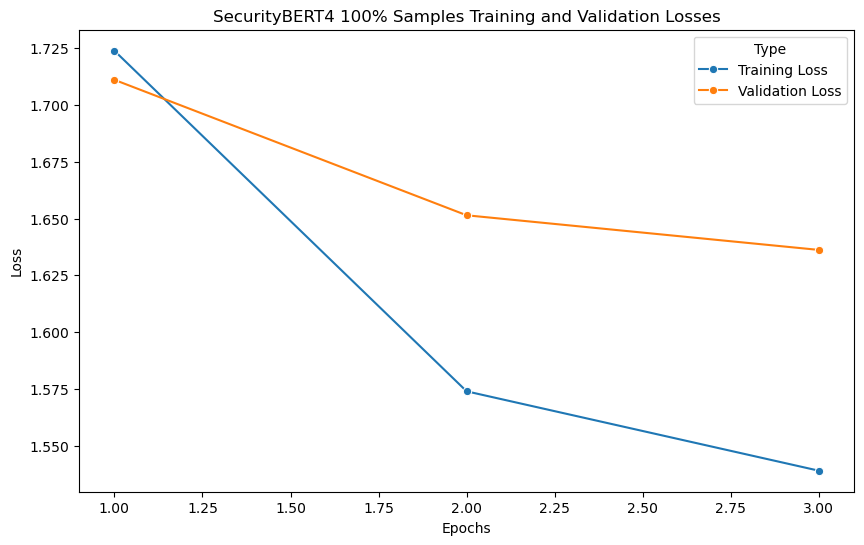

In [75]:
import matplotlib.pyplot as plt
import seaborn as sns

epochs = range(1, len(pretraining_history['train_acc'])+1)
train_losses = pretraining_history['train_loss']
print(train_losses)
val_losses = pretraining_history['val_loss']
print(val_losses)

df_plot = pd.DataFrame({
    "Epoch": epochs,
    "Training Loss": train_losses,
    "Validation Loss": val_losses
})

# Melt to long-form for seaborn
df_plot_long = df_plot.melt(id_vars="Epoch", var_name="Type", value_name="Loss")

plt.figure(figsize=(10, 6))
sns.lineplot(data=df_plot_long, x="Epoch", y="Loss", hue="Type", marker="o")
plt.title(f'{figure_version} Training and Validation Losses')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.savefig(f'./{figure_file_name}-{num_epochs}ep-training-validation-losses.png', dpi=780)
plt.show()

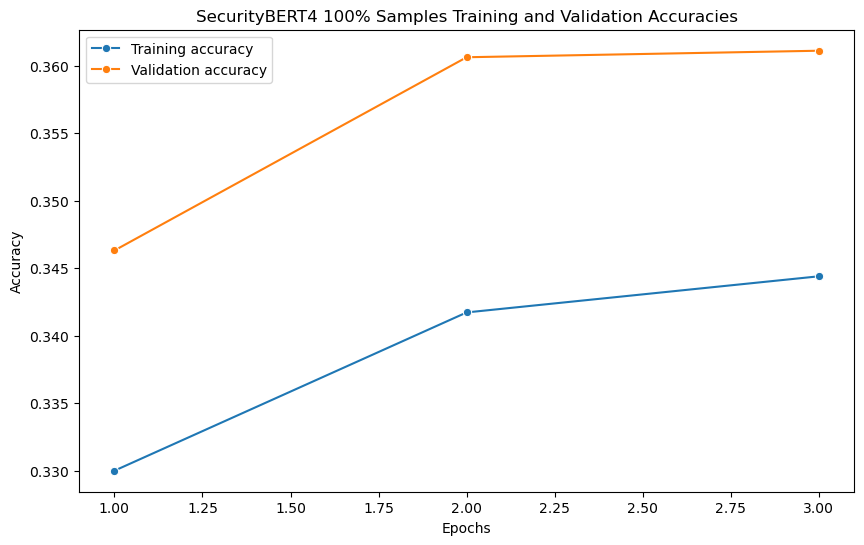

In [76]:
epochs = range(1, len(pretraining_history['train_acc'])+1)
train_accuracies = pretraining_history['train_acc']
val_accuracies = pretraining_history['val_acc']

plt.figure(figsize=(10, 6))

sns.lineplot(x=epochs, y=train_accuracies, label='Training accuracy',marker='o', data=None)
sns.lineplot(x=epochs, y=val_accuracies, label='Validation accuracy',marker='o', data=None)

plt.title(f'{figure_version} Training and Validation Accuracies')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.savefig(f'./{figure_file_name}-{num_epochs}ep-training-validation-accuracies.png',dpi=780)
plt.show()

In [77]:
def get_predictions(model,test_loader):
    model = model.eval()

    predictions,predictions_probs,real_values = [],[],[]

    with torch.no_grad():
        for data in tqdm(test_loader,desc="Predictions"):
            input_ids = data['input_ids'].to(device)
            attention_mask = data['attention_mask'].to(device)
            targets = data['targets'].to(device)

            outputs = model(input_ids,attention_mask)
            _,preds = torch.max(outputs,dim=1)

            probs = F.softmax(outputs,dim=1)

            predictions.extend(preds)
            predictions_probs.extend(probs)
            real_values.extend(targets)

    predictions = torch.stack(predictions).cpu()
    predictions_probs = torch.stack(predictions_probs).cpu()
    real_values = torch.stack(real_values).cpu()

    return predictions,predictions_probs,real_values



## Fine-tuning

In [ ]:
finetunedBERT = BertModel.from_pretrained(f"pretrained_model/bertPretrained_securityBERT4_{keep_frac}samples_1.0", local_files_only=True)
model_directory = "finetuned_model/"
model_version = f"bertFinetuned_securityBERT4_{keep_frac}samples"
figure_version = f"SecurityBERT4 {clean_float_str(keep_frac * 100)}% Samples Finetuning"
figure_file_name = f'bertFinetuned-securityBert4-{keep_frac}samples'
num_epochs=3

In [79]:
securityBert = SecurityBERT(finetunedBERT=finetunedBERT,n_classes=len(TARGET_LIST)).to(device)
EPOCHS=num_epochs
optimizer = torch.optim.AdamW(securityBert.parameters(),lr=1e-5)
total_steps = len(train_loader)*EPOCHS

scheduler = get_linear_schedule_with_warmup(
    optimizer,
    num_warmup_steps= 0,
    num_training_steps=total_steps
)
loss_fn = nn.CrossEntropyLoss().to(device)

In [80]:
%%time
history = defaultdict(list)
best_accuracy=0
for epoch in tqdm(range(EPOCHS)):
  print(f"Epoch {epoch+1}/{EPOCHS}")
  train_acc,train_loss = train_model(securityBert,train_loader,loss_fn,optimizer,device,scheduler,len(train_set))
  val_acc,val_loss = evaluation_model(securityBert,val_loader,loss_fn,device,len(val_set))
  history['train_acc'].append(train_acc)
  history['train_loss'].append(train_loss)
  history['val_acc'].append(val_acc)
  history['val_loss'].append(val_loss)
  print(f"Train Loss {train_loss} | Validation Loss {val_loss} |Training Accuracy {train_acc} |Validation Accuracy {val_acc}")

  if val_acc>best_accuracy:
    save_dir = './finetuned_model'
    # Create the directory if it doesn't exist
    os.makedirs(save_dir, exist_ok=True)
    torch.save(securityBert.state_dict(),f"./{model_directory}{model_version}{epoch+1}.0.pt")
    best_accuracy = val_acc


  0%|          | 0/3 [00:00<?, ?it/s]

Epoch 1/3
Train Loss 1.6870606874362895 | Validation Loss 1.1554238847784093 |Training Accuracy 0.36451202630996704 |Validation Accuracy 0.5547106266021729
Epoch 2/3
Train Loss 0.9048703495814515 | Validation Loss 0.7166586029368478 |Training Accuracy 0.6480626463890076 |Validation Accuracy 0.7493873834609985
Epoch 3/3
Train Loss 0.6143523561719672 | Validation Loss 0.571737202800609 |Training Accuracy 0.7837316393852234 |Validation Accuracy 0.7978876233100891
CPU times: total: 46min 9s
Wall time: 47min 7s


In [81]:
torch.save(history,f"./{model_directory}history_{model_version}.pt")
test_indices = test_set.index.to_numpy()
np.save(f"./{model_directory}test_indices_{model_version}.npy", test_indices)

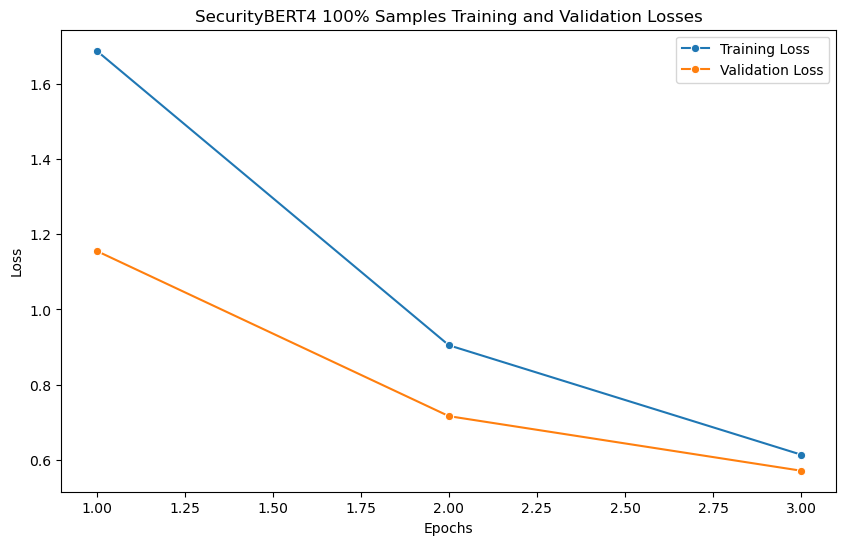

In [82]:

epochs = range(1, EPOCHS+1)
train_losses = history['train_loss']
val_losses = history['val_loss']

# Création du graphique
plt.figure(figsize=(10, 6))

# Tracé des courbes de training et de validation losses
sns.lineplot(x=epochs, y=train_losses, label='Training Loss',marker="o")
sns.lineplot(x=epochs, y=val_losses, label='Validation Loss',marker="o")

# Ajout de titres et de légendes
plt.title(f'{figure_version} Training and Validation Losses')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.savefig(f'./{figure_file_name}-{num_epochs}ep-training-validation-losses.png',dpi=780)
# Affichage du graphique
plt.show()


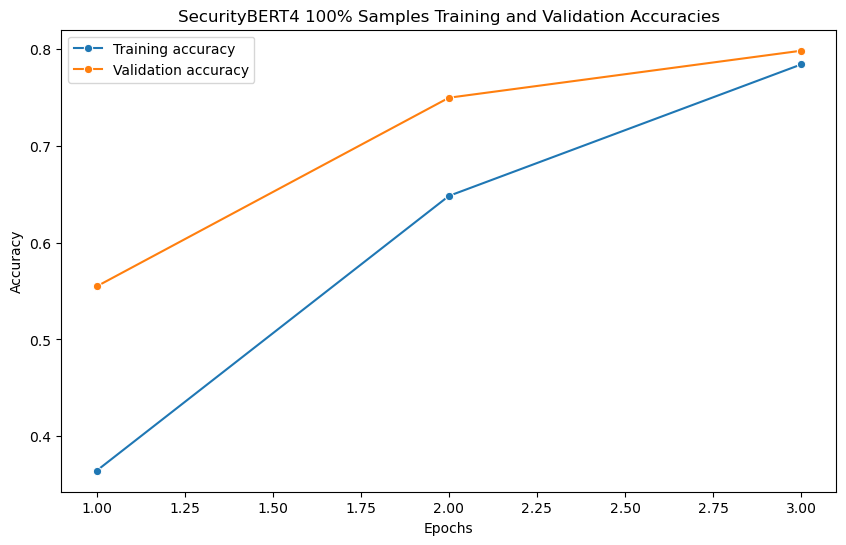

In [83]:
epochs = range(1, EPOCHS+1)
train_accuracies = [tens.item() for tens in history['train_acc']]
val_accuracies = [tens.item() for tens in history['val_acc']]

# Création du graphique
plt.figure(figsize=(10, 6))

# Tracé des courbes de training et de validation losses
sns.lineplot(x=epochs, y=train_accuracies, label='Training accuracy',marker='o')
sns.lineplot(x=epochs, y=val_accuracies, label='Validation accuracy',marker='o')

# Ajout de titres et de légendes
plt.title(f'{figure_version} Training and Validation Accuracies')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.savefig(f'./{figure_file_name}-{num_epochs}ep-training-validation-accuracies.png',dpi=780)
# Affichage du graphique
plt.show()


In [84]:
y_pred,y_proba,real_values = get_predictions(securityBert,test_loader)

Predictions:   0%|          | 0/740 [00:00<?, ?it/s]

In [85]:
torch.save(y_pred,f"./{model_directory}y_pred_{model_version}.pt")
torch.save(y_proba,f"./{model_directory}y_proba_{model_version}.pt")
torch.save(real_values,f"./{model_directory}real_values_{model_version}.pt")

In [86]:
from sklearn.metrics import confusion_matrix,classification_report

In [87]:
target_names = ['Backdoor', 'DDoS_HTTP', 'DDoS_ICMP', 'DDoS_TCP', 'DDoS_UDP',
       'Fingerprinting', 'MITM', 'Normal', 'Password', 'Port_Scanning',
       'Ransomware', 'SQL_injection', 'Uploading', 'Vulnerability_scanner',
       'XSS']

In [88]:
s = set()

In [89]:
for elt in y_pred:
  s.add(elt.item())

In [90]:
actual_considered_classes = [TARGET_LIST[i] for i in s]
actual_considered_classes

['Backdoor',
 'DDoS_HTTP',
 'DDoS_ICMP',
 'DDoS_TCP',
 'DDoS_UDP',
 'Normal',
 'Password',
 'Port_Scanning',
 'Ransomware',
 'SQL_injection',
 'Uploading',
 'Vulnerability_scanner',
 'XSS']

In [91]:
data['Attack_type'].value_counts()

Attack_type
Normal                   24301
DDoS_UDP                 14498
DDoS_ICMP                14090
Ransomware               10925
DDoS_HTTP                10561
SQL_injection            10311
Uploading                10269
DDoS_TCP                 10247
Backdoor                 10195
Vulnerability_scanner    10076
Port_Scanning            10071
XSS                      10052
Password                  9989
MITM                      1214
Fingerprinting            1001
Name: count, dtype: int64

In [92]:
def show_confusion_matrix(confusion_matrix):

    plt.figure(figsize=(10, 8))
    sns.heatmap(confusion_matrix, annot=True, cmap='Blues', fmt='d')
    plt.xticks(rotation=90)
    plt.title(f"{figure_version} {num_epochs} Epochs Confusion Matrix")
    plt.ylabel('Real threats')
    plt.xlabel('Predicted threats')
    plt.savefig(f'./{figure_file_name}-{num_epochs}ep-confusion-matrix.png',dpi=780)
    plt.show()

In [93]:
from sklearn.metrics import confusion_matrix,classification_report

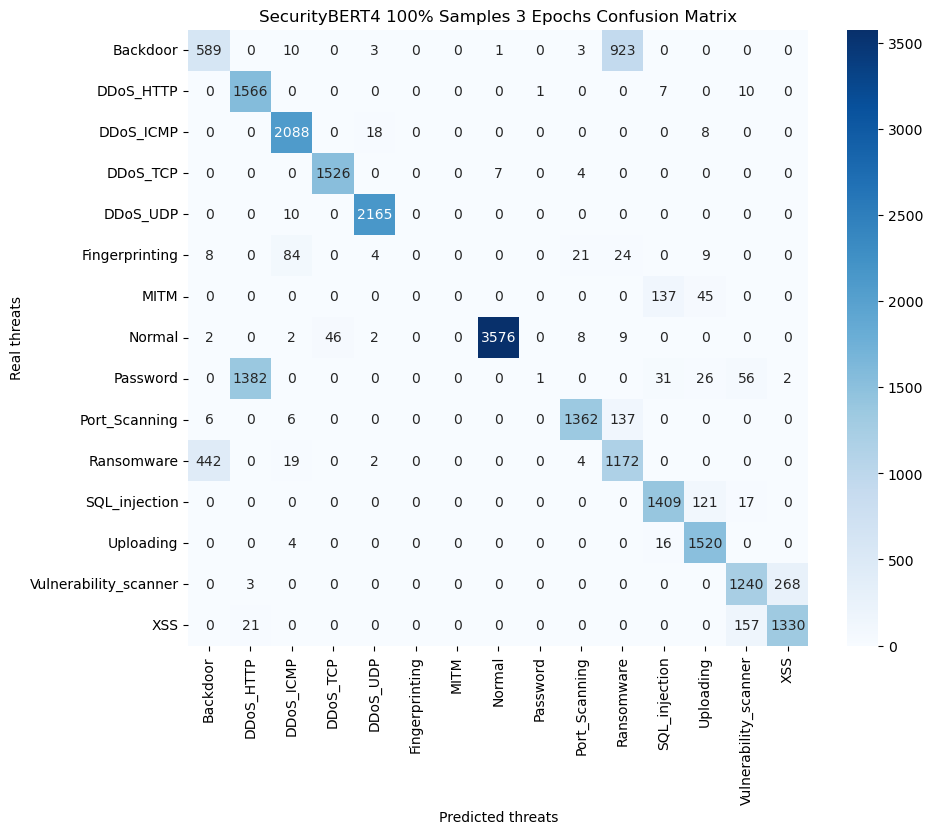

In [94]:
cm = confusion_matrix(real_values,y_pred)
df_cm = pd.DataFrame(cm,index=TARGET_LIST,columns=TARGET_LIST)
show_confusion_matrix(df_cm)

In [95]:
print(classification_report(real_values,y_pred,target_names=TARGET_LIST))

                       precision    recall  f1-score   support

             Backdoor       0.56      0.39      0.46      1529
            DDoS_HTTP       0.53      0.99      0.69      1584
            DDoS_ICMP       0.94      0.99      0.96      2114
             DDoS_TCP       0.97      0.99      0.98      1537
             DDoS_UDP       0.99      1.00      0.99      2175
       Fingerprinting       0.00      0.00      0.00       150
                 MITM       0.00      0.00      0.00       182
               Normal       1.00      0.98      0.99      3645
             Password       0.50      0.00      0.00      1498
        Port_Scanning       0.97      0.90      0.94      1511
           Ransomware       0.52      0.72      0.60      1639
        SQL_injection       0.88      0.91      0.90      1547
            Uploading       0.88      0.99      0.93      1540
Vulnerability_scanner       0.84      0.82      0.83      1511
                  XSS       0.83      0.88      0.86  

In [96]:
s = set()
for elt in y_pred:
    s.add(elt.item())
actual_considered_classes = [le.classes_[i] for i in s]
print(actual_considered_classes)

counts = test_set['target'].value_counts().sort_index()
class_names = le.inverse_transform(counts.index)
class_counts = pd.Series(counts.values, index=class_names)
class_counts = class_counts.sort_values(ascending=False)  # or .sort_index()
print(class_counts)

['Backdoor', 'DDoS_HTTP', 'DDoS_ICMP', 'DDoS_TCP', 'DDoS_UDP', 'Normal', 'Password', 'Port_Scanning', 'Ransomware', 'SQL_injection', 'Uploading', 'Vulnerability_scanner', 'XSS']
Normal                   3645
DDoS_UDP                 2175
DDoS_ICMP                2114
Ransomware               1639
DDoS_HTTP                1584
SQL_injection            1547
Uploading                1540
DDoS_TCP                 1537
Backdoor                 1529
Port_Scanning            1511
Vulnerability_scanner    1511
XSS                      1508
Password                 1498
MITM                      182
Fingerprinting            150
dtype: int64


In [97]:
y_true = real_values.cpu().numpy()
y_score = y_pred.cpu().numpy()

In [98]:
import matplotlib.pyplot as plt

def plot_test_metrics_table(test_metrics, figure_version, num_epochs, figure_file_name):
    """
    Plots and saves a table of test metrics as a figure.

    Parameters:
    - test_metrics: defaultdict or dict with scalar values
    - figure_version: str (e.g., 'v1.0')
    - num_epochs: int
    - figure_file_name: str (e.g., 'tab-transformer')
    """

    # Define a mapping from metric keys to display names
    metric_name_map = {
        "micro_acc": "Overall Accuracy",
        "micro_rec": "Overall Recall",
        "micro_prec": "Overall Precision",
        "micro_f1": "Overall F1 Score",
        "micro_roc_auc": "Overall ROC AUC",
        "macro_acc": "Class-Averaged Accuracy",
        "macro_rec": "Class-Averaged Recall",
        "macro_prec": "Class-Averaged Precision",
        "macro_f1": "Class-Averaged F1 Score",
        "macro_roc_auc": "Class-Averaged ROC AUC",
        # Add more mappings as needed
    }

    # Convert metrics to a list of [metric_name, value] rows
    data = []
    for key, value in test_metrics.items():
        label = metric_name_map.get(key, key)  # Use key as fallback if not in map
        data.append([label, f"{value:.4f}"])

    fig, ax = plt.subplots(figsize=(8, len(data) * 0.4 + 1))
    ax.axis('off')

    table = ax.table(
        cellText=data,
        colLabels=["Metric", "Score"],
        loc='center',
        cellLoc='center'
    )
    table.auto_set_font_size(False)
    table.set_fontsize(12)
    table.scale(1, 1.5)

    plt.title(f"{figure_version} {num_epochs} Epochs Test Scores", fontsize=14, pad=20)

    output_path = f"./{figure_file_name}-{num_epochs}ep-test-scores.png"
    plt.savefig(output_path, dpi=300, bbox_inches='tight')
    plt.show()


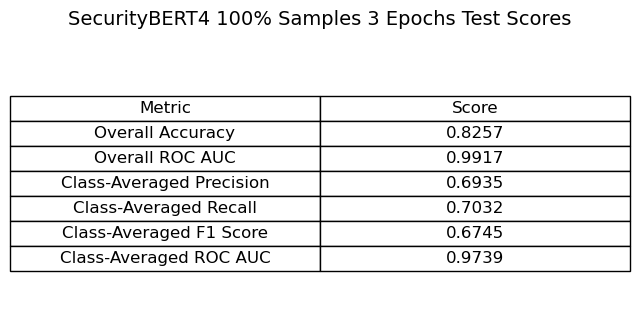

In [99]:
from collections import defaultdict
from sklearn.preprocessing import label_binarize
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
)
import numpy as np
import torch
from sklearn.metrics import balanced_accuracy_score

# Assume these are already defined:
# y_true: true class labels (1D array-like)
# y_pred: predicted class labels (1D array-like)
# y_proba: predicted probabilities (2D array-like: [n_samples, n_classes])

n_classes = len(np.unique(y_true))
y_true_bin = label_binarize(y_true, classes=np.arange(n_classes))

test_metrics = defaultdict(float)  # ⬅️ Each key holds a single float value

# Micro metrics
test_metrics["micro_acc"] = accuracy_score(y_true, y_pred)
try:
    test_metrics["micro_roc_auc"] = roc_auc_score(
        y_true_bin, y_proba, average="micro", multi_class="ovr"
    )
except ValueError:
    test_metrics["micro_roc_auc"] = float("nan")

test_metrics["macro_prec"] = precision_score(y_true, y_pred, average="macro", zero_division=0)
test_metrics["macro_rec"] = recall_score(y_true, y_pred, average="macro", zero_division=0)
test_metrics["macro_f1"] = f1_score(y_true, y_pred, average="macro")

# ROC AUC Scores
try:
    test_metrics["macro_roc_auc"] = roc_auc_score(
        y_true_bin, y_proba, average="macro", multi_class="ovr"
    )
except ValueError:
    test_metrics["macro_roc_auc"] = float("nan")

# Save metrics
torch.save(dict(test_metrics), f"./{model_directory}test_metrics_{model_version}.pt")

# Plot
plot_test_metrics_table(test_metrics, figure_version=figure_version, num_epochs=num_epochs, figure_file_name=figure_file_name)